# 16 — Descriptive statistics

Counts of rules, groups, resources, authors and works — overall and per period — on `rules_dataset_april_2026.tsv`.

In [1]:
import pandas as pd

DATA_PATH = "../data/rules_dataset_april_2026.tsv"
df = pd.read_csv(DATA_PATH, sep="\t")
print(df.shape)
df.head(2)

(1011, 34)


,rule_id,perseus_author,perseus_title,period,source_type,source_type_description,rule,verbatim,reasoning,directionality,...,resource_persistence,persistence_reasoning,group_immutability,immutability_reasoning,rule_contemporarity,contemporarity_reasoning,opinion_vs_fact,opinion_vs_fact_reasoning,tautology,tautology_reasoning
0,tlg0007.tlg118.perseus-eng3::0,Plutarch,Precepts of Statecraft,Hellenistic & Early Roman (165 BCE – 105 CE),contemporary_treatise,Contemporary philosophical / political treatis...,Greek exclusion from large-scale statecraft,['The exercise of statecraft on a large scale ...,The text describes a systematic restriction wh...,LESS,...,4,Exclusion from high office is a durable career...,5,Greek ethnicity is a birth-fixed biological/cu...,1,Plutarch describes the current Roman administr...,5,Verbatim states the limitation as a plain hist...,0,Ethnicity does not inherently define level of ...
1,tlg0007.tlg118.perseus-eng3::1,Plutarch,Precepts of Statecraft,Hellenistic & Early Roman (165 BCE – 105 CE),contemporary_treatise,Contemporary philosophical / political treatis...,City-state local self-government,"['The ancient Greek city-states retained, howe...","Under Roman rule, Greek citizens retained spec...",MORE,...,5,A city's status and its citizens' collective r...,4,Citizenship in a Greek city-state is a rigid l...,1,Refers to the existing status of Greek cities ...,5,Describes the retention of local rights as a r...,0,Being a citizen of a city does not inherently ...


## Overall counts

In [2]:
n_rules = len(df)
n_groups = df["group"].nunique(dropna=True)
n_resources = df["resource"].nunique(dropna=True)
n_authors = df["perseus_author"].nunique(dropna=True)
n_works = df["perseus_title"].nunique(dropna=True)
n_periods = df["period"].nunique(dropna=True)

overall = pd.Series({
    "total_rules": n_rules,
    "unique_groups": n_groups,
    "unique_resources": n_resources,
    "unique_authors": n_authors,
    "unique_works": n_works,
    "unique_periods": n_periods,
}, name="count")
overall

total_rules         1011
unique_groups        291
unique_resources     722
unique_authors        21
unique_works         122
unique_periods         4
Name: count, dtype: int64

## Per period

Number of rules, unique groups, and unique resources within each period.

In [3]:
per_period = (
    df.groupby("period", dropna=False)
      .agg(
          n_rules=("rule_id", "count"),
          unique_groups=("group", pd.Series.nunique),
          unique_resources=("resource", pd.Series.nunique),
          unique_authors=("perseus_author", pd.Series.nunique),
          unique_works=("perseus_title", pd.Series.nunique),
      )
      .sort_values("n_rules", ascending=False)
)
per_period

,n_rules,unique_groups,unique_resources,unique_authors,unique_works
period,,,,,
Late Classical (354–165 BCE),397,123,287,4,29
Classical (500–360 BCE),283,95,235,9,44
Hellenistic & Early Roman (165 BCE – 105 CE),155,81,135,4,32
NaN,91,36,80,1,1
High Roman Empire (135–205 CE),85,45,75,3,16


## Per period × directionality

In [4]:
per_period_dir = (
    df.groupby(["period", "directionality"], dropna=False)
      .size()
      .unstack(fill_value=0)
)
per_period_dir["total"] = per_period_dir.sum(axis=1)
per_period_dir.sort_values("total", ascending=False)

directionality,LESS,MORE,total
period,,,
Late Classical (354–165 BCE),192,205,397
Classical (500–360 BCE),113,170,283
Hellenistic & Early Roman (165 BCE – 105 CE),66,89,155
NaN,47,44,91
High Roman Empire (135–205 CE),44,41,85


## Visual summary

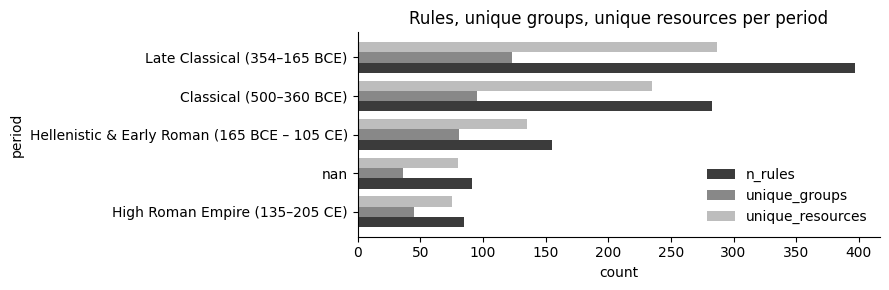

In [5]:
import matplotlib.pyplot as plt

plot_df = per_period[["n_rules", "unique_groups", "unique_resources"]].sort_values("n_rules")

fig, ax = plt.subplots(figsize=(9, max(3, 0.45 * len(plot_df))))
plot_df.plot(kind="barh", ax=ax, color=["#3b3b3b", "#888888", "#bdbdbd"], width=0.8)
ax.set_xlabel("count")
ax.set_ylabel("period")
ax.set_title("Rules, unique groups, unique resources per period")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()